In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style("whitegrid")

In [2]:
data1 = pd.read_csv("../../runs/PPO-{SafeAgentBaseSauteInvertedPendulum-v4}/seed-000-2026-04-14-12-59-59/progress.csv")

In [3]:
data2 = pd.read_csv("../../runs/PPO-{SafeAgentAdvancedSauteInvertedPendulum-v4}/seed-000-2026-04-14-14-21-26/progress.csv")

In [6]:
data1.describe()

,Metrics/EpRet,Metrics/EpCost,Metrics/EpLen,Train/Epoch,Train/Entropy,Train/KL,Train/StopIter,Train/PolicyRatio,Train/PolicyRatio/Min,Train/PolicyRatio/Max,...,Loss/Loss_pi/Delta,Value/Adv,Loss/Loss_reward_critic,Loss/Loss_reward_critic/Delta,Value/reward,Time/Total,Time/Rollout,Time/Update,Time/Epoch,Time/FPS
count,100.000000,100.000000,100.0,100.000000,100.000000,100.000000,100.0,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,-375.890832,277.510912,1001.0,49.500000,1.003467,0.004777,40.0,0.999242,0.999242,0.999242,...,-0.000023,0.025054,5.901789,0.018042,-48.216630,2465.114409,11.579102,37.263685,48.842820,409.621160
std,216.634320,72.733412,0.0,29.011492,0.189484,0.000787,0.0,0.000854,0.000854,0.000854,...,0.000950,0.160030,4.316080,2.111319,20.937732,1415.892682,0.207014,0.841722,0.924600,7.709280
min,-936.821228,218.159851,1001.0,0.000000,0.658360,0.002326,40.0,0.997209,0.997209,0.997209,...,-0.002600,-0.366726,1.630141,-5.828992,-87.463364,46.026394,10.988026,34.948177,46.026169,383.102570
25%,-378.975830,240.479771,1001.0,24.750000,0.865080,0.004274,40.0,0.998664,0.998664,0.998664,...,-0.000571,-0.087766,2.271474,-0.555728,-64.116686,1263.159302,11.458731,36.704726,48.289903,406.035004
50%,-272.029358,253.206100,1001.0,49.500000,1.001878,0.004846,40.0,0.999232,0.999232,0.999232,...,-0.000167,0.014859,4.149192,-0.081017,-46.291689,2460.692749,11.594252,37.108515,48.782625,409.982086
75%,-241.766785,274.306427,1001.0,74.250000,1.142644,0.005275,40.0,0.999892,0.999892,0.999892,...,0.000492,0.131978,9.347260,0.571399,-28.804862,3673.379517,11.705979,37.762458,49.256837,414.165283
max,-218.159851,556.674072,1001.0,99.000000,1.399847,0.006464,40.0,1.001128,1.001128,1.001128,...,0.002904,0.361728,17.551840,11.873304,0.048346,4886.117188,12.056508,40.458542,52.205341,434.535400


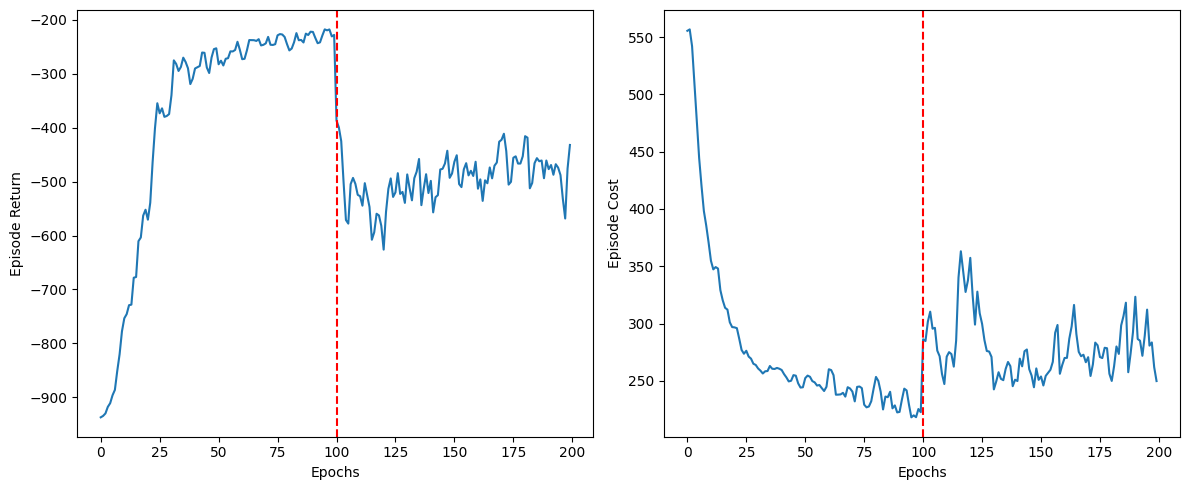

In [16]:
x = np.arange(len(data1['Metrics/EpRet']) + len(data2['Metrics/EpRet']))

fig,ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(x, np.concatenate([data1['Metrics/EpRet'], data2['Metrics/EpRet']]))
ax[0].axvline(len(data1['Metrics/EpRet']), color='red', linestyle='--') 
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Episode Return')

ax[1].plot(x, np.concatenate([data1['Metrics/EpCost'], data2['Metrics/EpCost']]))
ax[1].axvline(len(data1['Metrics/EpCost']), color='red', linestyle='--')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Episode Cost')
fig.tight_layout()

In [60]:
data = np.load("../../runs/PPO-{SafeAgentSautePointCircle2-v0}/seed-000-2026-04-27-11-45-16/SafeAgentSautePointCircle2-v0_data_0.npz")



In [5]:
for key in data.keys():
    print(key)

obs
action
reward
cost
next_obs
done


In [61]:
data['obs'].shape

(100000, 29)

In [47]:
df = pd.DataFrame({'reward': data['reward'].squeeze(), 'cost': data['cost'].squeeze(), 'cost_budget': data['obs'][:, -1].squeeze(), 'done': data['done'].squeeze()})

In [48]:
df_budget_exceeded= df.where(df['reward'] == -100)

In [49]:
df_trajectory_ends = df.where(df['done'] == True)

In [50]:
df_trajectory_ends.describe()

,reward,cost,cost_budget,done
count,494.000000,494.000000,494.000000,494.0
mean,-82.192673,0.821862,0.264141,1.0
std,38.287807,0.383016,0.619415,0.0
min,-100.000000,0.000000,-0.039988,1.0
25%,-100.000000,1.000000,-0.024866,1.0
50%,-100.000000,1.000000,-0.014481,1.0
75%,-100.000000,1.000000,-0.003196,1.0
max,0.040664,1.000000,1.647485,1.0


In [51]:
df_budget_exceeded.count()[0] / df_trajectory_ends.count()[0]

0.8218623481781376

In [52]:
df.describe()

,reward,cost,cost_budget,done
count,100000.000000,100000.00000,100000.000000,100000.000000
mean,-0.434087,0.12157,1.071438,0.004940
std,6.357192,0.32679,0.333553,0.070112
min,-100.000000,0.00000,-0.039988,0.000000
25%,-0.055180,0.00000,1.016137,0.000000
50%,-0.030160,0.00000,1.075770,0.000000
75%,-0.004232,0.00000,1.260005,0.000000
max,0.073429,1.00000,1.647485,1.000000


In [53]:
df['episode_id'] = df['done'].cumsum()
df['episode_id'] = df['episode_id'].shift(1).fillna(0).astype(int)
df['step'] = df.groupby('episode_id').cumcount()

In [54]:
df.where(df['done'] == True)

,reward,cost,cost_budget,done,episode_id,step
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
99995,NaN,NaN,NaN,NaN,NaN,NaN
99996,NaN,NaN,NaN,NaN,NaN,NaN
99997,NaN,NaN,NaN,NaN,NaN,NaN
99998,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
trajectories = [group for _, group in df.groupby('episode_id')]

In [56]:
safe_trajectories = []
unsafe_trajectories = []

for traj in trajectories:
    if -100 in traj['reward'].values:
        unsafe_trajectories.append(traj)
    else:
        safe_trajectories.append(traj)

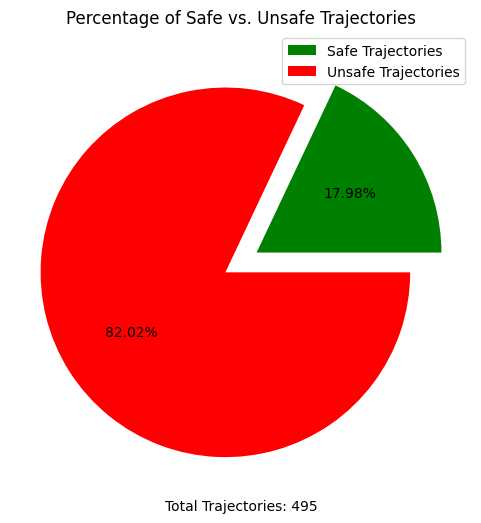

In [57]:
plt.figure(figsize=(6, 6))

wedges, texts, autotexts = plt.pie([len(safe_trajectories), len(unsafe_trajectories)], autopct='%1.2f%%', colors=['green', 'red'], explode=(0.1, 0.1), textprops={'color': 'black'})
plt.legend(wedges, ['Safe Trajectories', 'Unsafe Trajectories'], loc='upper right')
plt.title('Percentage of Safe vs. Unsafe Trajectories')
plt.xlabel("Total Trajectories: {}".format(len(trajectories)))
plt.grid(True, axis='y')
plt.savefig("./plots/inverted_pendulum_trajectory_safety_pie_chart.png")
plt.show()


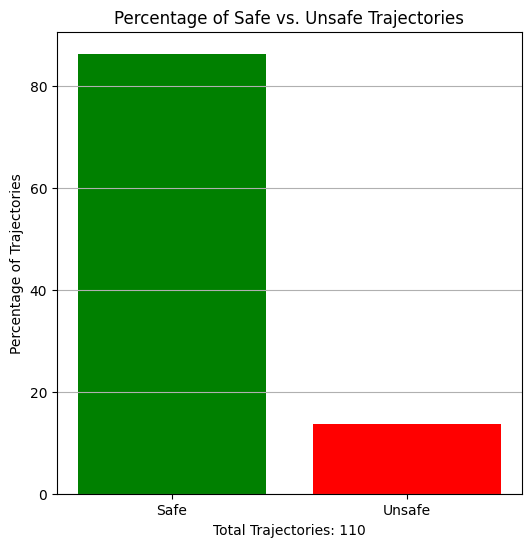

In [45]:
plt.figure(figsize=(6, 6))

plt.bar(['Safe', 'Unsafe'], [len(safe_trajectories)/ len(trajectories) *100, len(unsafe_trajectories)/ len(trajectories) *100], color=['green', 'red'])
plt.title('Percentage of Safe vs. Unsafe Trajectories')
plt.xlabel("Total Trajectories: {}".format(len(trajectories)))
plt.ylabel('Percentage of Trajectories')
plt.grid(True, axis='y')
plt.savefig("./plots/inverted_pendulum_trajectory_safety_bar_chart.pdf")
plt.show()